# Proyek Eksperimen Sistem Machine Learning: Telco Customer Churn

Notebook ini mengikuti template eksperimen MSML untuk melakukan eksplorasi dataset, EDA, dan preprocessing data sebelum digunakan pada tahap pelatihan model.

## 1. Perkenalan Dataset

Dataset yang digunakan adalah **Telco Customer Churn Dataset**. Dataset ini berisi informasi pelanggan perusahaan telekomunikasi, seperti jenis kontrak, layanan internet, biaya bulanan, total biaya, lama berlangganan, dan status churn.

Tujuan proyek ini adalah memprediksi apakah seorang pelanggan akan melakukan **churn** atau tidak berdasarkan karakteristik dan riwayat layanan pelanggan.

- Jenis masalah: **Supervised Learning - Binary Classification**
- Target: `Churn`
- Nilai target:
  - `Yes`: pelanggan berhenti berlangganan
  - `No`: pelanggan tetap berlangganan

Sumber dataset:
https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv

## 2. Import Library

In [ ]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")

## 3. Memuat Dataset

In [ ]:
DATA_URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
RAW_DATA_PATH = "../telco_churn_raw.csv"

if os.path.exists(RAW_DATA_PATH):
    df = pd.read_csv(RAW_DATA_PATH)
else:
    df = pd.read_csv(DATA_URL)
    df.to_csv(RAW_DATA_PATH, index=False)

print("Shape dataset:", df.shape)
df.head()

Shape dataset: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


## 4. Exploratory Data Analysis (EDA)

Tahapan EDA dilakukan untuk memahami struktur dataset, distribusi fitur, missing value, duplikasi data, dan hubungan antar fitur sebelum melakukan preprocessing.

In [ ]:
# Cek missing value
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# Cek data duplikat
print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 0


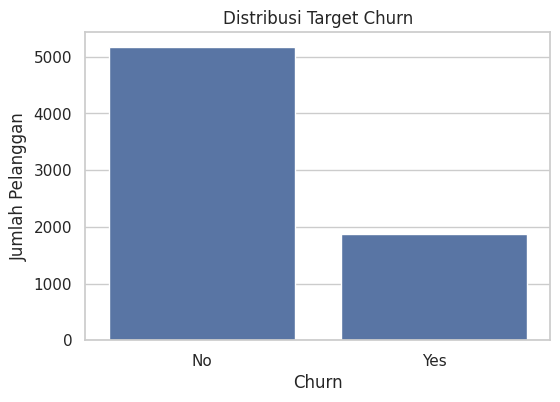

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [ ]:
# Distribusi target Churn
plt.figure(figsize=(6, 4))
sns.countplot(x="Churn", data=df)
plt.title("Distribusi Target Churn")
plt.xlabel("Churn")
plt.ylabel("Jumlah Pelanggan")
plt.show()

print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True) * 100)

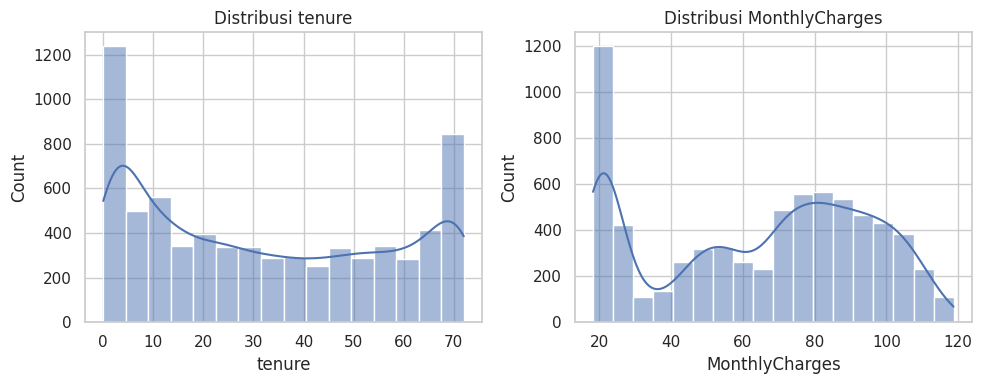

In [ ]:
# Distribusi fitur numerik utama
numeric_columns = ["tenure", "MonthlyCharges"]

plt.figure(figsize=(10, 4))
for i, col in enumerate(numeric_columns, 1):
    plt.subplot(1, 2, i)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribusi {col}")
plt.tight_layout()
plt.show()

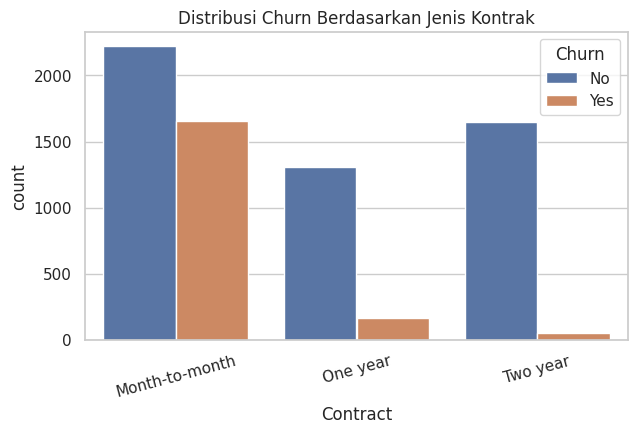

In [ ]:
# Hubungan Contract dengan Churn
plt.figure(figsize=(7, 4))
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Distribusi Churn Berdasarkan Jenis Kontrak")
plt.xticks(rotation=15)
plt.show()

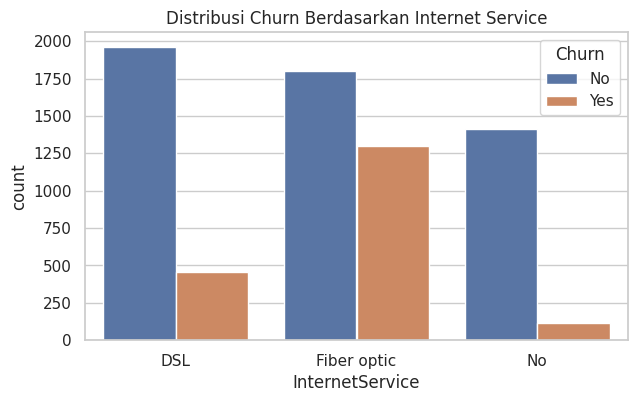

In [ ]:
# Hubungan InternetService dengan Churn
plt.figure(figsize=(7, 4))
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title("Distribusi Churn Berdasarkan Internet Service")
plt.show()

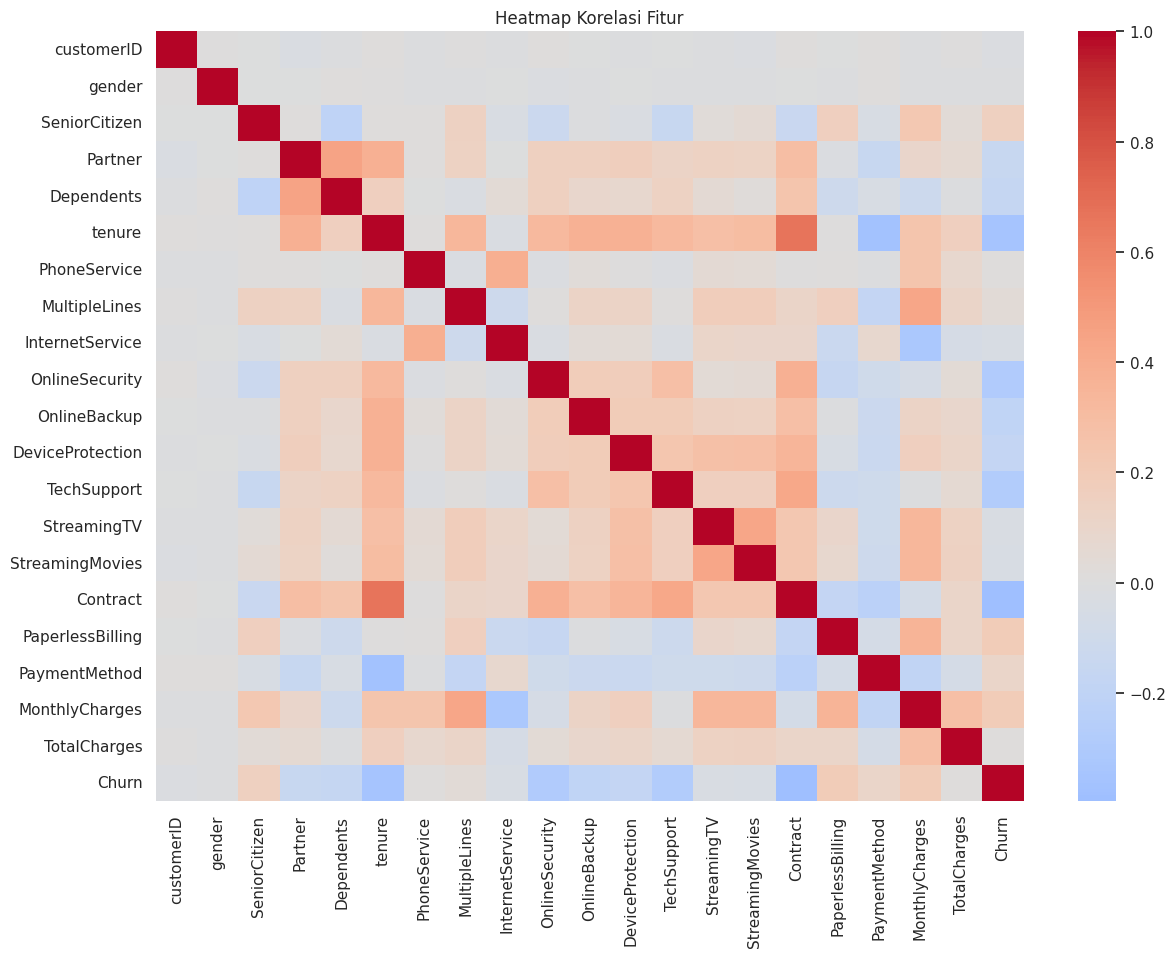

In [ ]:
# Korelasi fitur setelah encoding sementara untuk kebutuhan EDA
eda_df = df.copy()

for column in eda_df.select_dtypes(include="object").columns:
    eda_df[column] = LabelEncoder().fit_transform(eda_df[column].astype(str))

plt.figure(figsize=(14, 10))
sns.heatmap(eda_df.corr(), cmap="coolwarm", center=0)
plt.title("Heatmap Korelasi Fitur")
plt.show()

## 5. Data Preprocessing

Tahapan preprocessing dilakukan agar dataset siap digunakan untuk pelatihan model. Tahapan ini nantinya dikonversi ke file `automate_RaihanFahrezi.py` untuk memenuhi kriteria Skilled.

Tahapan preprocessing:
1. Menghapus kolom `customerID` karena hanya merupakan identifier.
2. Mengubah kolom `TotalCharges` menjadi numerik.
3. Mengisi missing value pada `TotalCharges` menggunakan median.
4. Melakukan encoding pada seluruh fitur kategorikal.
5. Menyimpan dataset hasil preprocessing.

In [ ]:
df_preprocessed = df.copy()

# Menghapus kolom identifier
if "customerID" in df_preprocessed.columns:
    df_preprocessed = df_preprocessed.drop("customerID", axis=1)

# Mengubah TotalCharges menjadi numerik
# Pada dataset raw, TotalCharges dapat terbaca sebagai object karena ada nilai kosong.
df_preprocessed["TotalCharges"] = pd.to_numeric(
    df_preprocessed["TotalCharges"],
    errors="coerce"
)

# Mengisi missing value TotalCharges dengan median
df_preprocessed["TotalCharges"] = df_preprocessed["TotalCharges"].fillna(
    df_preprocessed["TotalCharges"].median()
)

# Encoding fitur kategorikal
encoder = LabelEncoder()

for column in df_preprocessed.select_dtypes(include="object").columns:
    df_preprocessed[column] = encoder.fit_transform(
        df_preprocessed[column].astype(str)
    )

print("Shape dataset setelah preprocessing:", df_preprocessed.shape)
df_preprocessed.head()

Shape dataset setelah preprocessing: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [ ]:
# Validasi hasil preprocessing
print("Missing value setelah preprocessing:")
print(df_preprocessed.isnull().sum().sum())

print("\nTipe data setelah preprocessing:")
print(df_preprocessed.dtypes.value_counts())

print("\nDistribusi target setelah encoding:")
print(df_preprocessed["Churn"].value_counts())

Missing value setelah preprocessing:
0

Tipe data setelah preprocessing:
int64      18
float64     2
Name: count, dtype: int64

Distribusi target setelah encoding:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [ ]:
# Menyimpan dataset hasil preprocessing
OUTPUT_PATH = "telco_churn_preprocessed.csv"
df_preprocessed.to_csv(OUTPUT_PATH, index=False)

print(f"Dataset hasil preprocessing berhasil disimpan ke: {OUTPUT_PATH}")

Dataset hasil preprocessing berhasil disimpan ke: telco_churn_preprocessed.csv


## Kesimpulan Eksperimen

Berdasarkan tahapan EDA dan preprocessing, dataset Telco Customer Churn telah berhasil diproses menjadi format numerik yang siap digunakan untuk pelatihan model machine learning.

File hasil preprocessing yang dihasilkan:

```text
telco_churn_preprocessed.csv
```

Tahapan preprocessing pada notebook ini telah dikonversi ke file Python otomatis:

```text
automate_RaihanFahrezi.py
```

Dengan demikian, proses preprocessing dapat dijalankan ulang secara otomatis untuk menghasilkan dataset siap latih.